# Airbnb NYC — Data Cleaning & EDA
### Python Cleaning Pipeline | Before Loading to PostgreSQL

**Dataset:** Airbnb Open Data — New York City  
**Rows:** 102,599 | **Columns:** 26  
**Goal:** Understand, clean and prepare data for PostgreSQL + Booking Analysis

---


In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [90]:
df = pd.read_csv('Airbnb_Open_Data.csv',dtype = 'str')

In [91]:
print(f"Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print()
print("Columns:", df.columns.tolist())

Shape: 102,599 rows  x  26 columns

Columns: ['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules', 'license']


In [92]:
df.head(3)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,FALSE,strict,Private room,2020,$966,$193,10,9,10/19/2021,0.21,4,6,286,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,FALSE,moderate,Entire home/apt,2007,$142,$28,30,45,5/21/2022,0.38,4,2,228,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.9419,United States,US,TRUE,flexible,Private room,2005,$620,$124,3,0,NaN,NaN,5,1,352,"I encourage you to use my kitchen, cooking and...",NaN


In [93]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)

null_report = pd.DataFrame({
    'Null Count' : null_counts,
    'Null %'     : null_pct
}).sort_values('Null %', ascending=False)

null_report[null_report['Null Count'] > 0]

,Null Count,Null %
license,102597,100.00
house_rules,52131,50.81
last review,15893,15.49
reviews per month,15879,15.48
country,532,0.52
availability 365,448,0.44
host name,406,0.40
minimum nights,409,0.40
review rate number,326,0.32
calculated host listings count,319,0.31


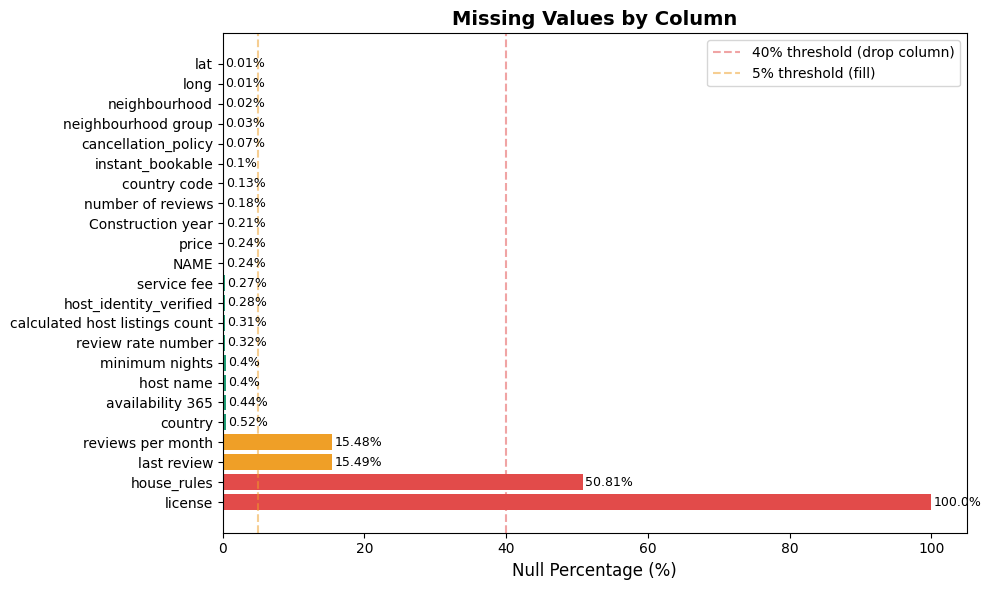

Red   = Drop the column (too many nulls, no value)
Amber = Fill with appropriate value
Green = Small null count, easy to handle


In [94]:
# Visualise null percentages
fig, ax = plt.subplots(figsize=(10, 6))

cols_with_nulls = null_report[null_report['Null Count'] > 0]
colors = ['#E24B4A' if p > 40 else '#EF9F27' if p > 5 else '#1D9E75'
          for p in cols_with_nulls['Null %']]

bars = ax.barh(cols_with_nulls.index, cols_with_nulls['Null %'], color=colors)

ax.set_xlabel('Null Percentage (%)', fontsize=12)
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
ax.axvline(x=40, color='#E24B4A', linestyle='--', alpha=0.5, label='40% threshold (drop column)')
ax.axvline(x=5,  color='#EF9F27', linestyle='--', alpha=0.5, label='5% threshold (fill)')
ax.legend(fontsize=10)

for bar, pct in zip(bars, cols_with_nulls['Null %']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Red   = Drop the column (too many nulls, no value)")
print("Amber = Fill with appropriate value")
print("Green = Small null count, easy to handle")

In [95]:
total_dupes  = df.duplicated().sum()
id_dupes     = df['id'].duplicated().sum()

print(f"Fully duplicate rows : {total_dupes}")
print(f"Duplicate listing IDs: {id_dupes}")
print()

# Preview a duplicate example
if id_dupes > 0:
    dup_id = df[df['id'].duplicated(keep=False)]['id'].iloc[540]
    print(f"Example — listing ID '{dup_id}' appears multiple times:")
    display(df[df['id'] == dup_id][['id', 'NAME', 'neighbourhood group', 'price']].head(3))

Fully duplicate rows : 541
Duplicate listing IDs: 541

Example — listing ID '35607902' appears multiple times:


,id,NAME,neighbourhood group,price
62659,35607902,Modern NEW Room|PRIVATE BATHROOM,Brooklyn,$284
102241,35607902,Modern NEW Room|PRIVATE BATHROOM,Brooklyn,$284


In [96]:
print("Columns BEFORE drop:", df.shape[1])
print()

cols_to_drop = {
    'license'      : '99.99% null — only 2 non-null rows in 102,599',
    'house_rules'  : '50.8% null — free text, no analytical value',
    'country'      : 'Zero variance — every row is United States',
    'country code' : 'Zero variance — every row is US',
    'NAME'         : 'Listing title text — not needed for booking analysis'
}

for col, reason in cols_to_drop.items():
    print(f"  Dropping '{col}': {reason}")

df.drop(columns=list(cols_to_drop.keys()), inplace=True)

print()
print(f"Columns AFTER drop : {df.shape[1]}")
print(f"Remaining columns  : {df.columns.tolist()}")

Columns BEFORE drop: 26

  Dropping 'license': 99.99% null — only 2 non-null rows in 102,599
  Dropping 'house_rules': 50.8% null — free text, no analytical value
  Dropping 'country': Zero variance — every row is United States
  Dropping 'country code': Zero variance — every row is US
  Dropping 'NAME': Listing title text — not needed for booking analysis

Columns AFTER drop : 21
Remaining columns  : ['id', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365']


In [97]:
before = len(df)

df.drop_duplicates(subset=['id'], keep='first', inplace=True)

removed = before - len(df)
print(f"Rows before : {before:,}")
print(f"Rows after  : {len(df):,}")
print(f"Removed     : {removed} duplicate rows (kept first occurrence)")

Rows before : 102,599
Rows after  : 102,058
Removed     : 541 duplicate rows (kept first occurrence)


In [98]:
print("Before fix:")
print(df['neighbourhood group'].value_counts(dropna=False))
print()

typo_map = {
    'brookln'  : 'Brooklyn',
    'manhatan' : 'Manhattan'
}
df['neighbourhood group'] = df['neighbourhood group'].replace(typo_map)

print("After fix:")
print(df['neighbourhood group'].value_counts(dropna=False))

Before fix:
neighbourhood group
Manhattan        43557
Brooklyn         41630
Queens           13197
Bronx             2694
Staten Island      949
NaN                 29
brookln              1
manhatan             1
Name: count, dtype: int64

After fix:
neighbourhood group
Manhattan        43558
Brooklyn         41631
Queens           13197
Bronx             2694
Staten Island      949
NaN                 29
Name: count, dtype: int64


In [99]:
for col in ['price', 'service fee']:
    df[col] = df[col].str.replace(r'[\$,]', '', regex=True).str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Price — sample values after cleaning:")
print(df['price'].head(8).tolist())
print()
print(f"Price nulls     : {df['price'].isnull().sum()}")
print(f"Service fee nulls: {df['service fee'].isnull().sum()}")

Price — sample values after cleaning:
[966.0, 142.0, 620.0, 368.0, 204.0, 577.0, 71.0, 1060.0]

Price nulls     : 247
Service fee nulls: 273


In [100]:
# Converting All Numeric Columns
numeric_cols = [
    'minimum nights',
    'number of reviews',
    'reviews per month',
    'review rate number',
    'calculated host listings count',
    'availability 365',
    'Construction year',
    'lat',
    'long'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


print(df.dtypes)

id                                 object
host id                            object
host_identity_verified             object
host name                          object
neighbourhood group                object
neighbourhood                      object
lat                               float64
long                              float64
instant_bookable                   object
cancellation_policy                object
room type                          object
Construction year                 float64
price                             float64
service fee                       float64
minimum nights                    float64
number of reviews                 float64
last review                        object
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availability 365                  float64
dtype: object


In [101]:
critical_cols = ['price', 'availability 365', 'neighbourhood group',
                 'neighbourhood', 'room type', 'lat', 'long']

before = len(df)
df.dropna(subset=critical_cols, inplace=True)
print(f"Dropped {before - len(df):,} rows with nulls in critical columns: {critical_cols}")

Dropped 734 rows with nulls in critical columns: ['price', 'availability 365', 'neighbourhood group', 'neighbourhood', 'room type', 'lat', 'long']


In [102]:
# ── Fill non-critical nulls ──
fills = {
    'reviews per month'             : 0,
    'number of reviews'             : 0,
    'minimum nights'                : df['minimum nights'].median(),
    'review rate number'            : df['review rate number'].median(),
    'calculated host listings count': 1,
    'host_identity_verified'        : 'unconfirmed',
    'cancellation_policy'           : 'moderate',
    'instant_bookable'              : 'FALSE',
    'Construction year'             : df['Construction year'].median(),
    'service fee'                   : df['service fee'].median(),
    'host name'                     : 'Unknown',
    'last review'                   : 'No reviews',
}

for col, val in fills.items():
    n = df[col].isnull().sum()
    if n > 0:
        df[col].fillna(val, inplace=True)
        print(f"  Filled {n:>5} nulls in '{col}'  →  {repr(round(val, 2) if isinstance(val, float) else val)}")

print()
print("Remaining nulls after filling:")
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else "None — all nulls handled.")

  Filled 15527 nulls in 'reviews per month'  →  0
  Filled   129 nulls in 'number of reviews'  →  0
  Filled   376 nulls in 'minimum nights'  →  np.float64(3.0)
  Filled   303 nulls in 'review rate number'  →  np.float64(3.0)
  Filled   319 nulls in 'calculated host listings count'  →  1
  Filled   271 nulls in 'host_identity_verified'  →  'unconfirmed'
  Filled    62 nulls in 'cancellation_policy'  →  'moderate'
  Filled    91 nulls in 'instant_bookable'  →  'FALSE'
  Filled   186 nulls in 'Construction year'  →  np.float64(2012.0)
  Filled   239 nulls in 'service fee'  →  np.float64(125.0)
  Filled   386 nulls in 'host name'  →  'Unknown'
  Filled 15535 nulls in 'last review'  →  'No reviews'

Remaining nulls after filling:
None — all nulls handled.


In [103]:
before = len(df)

# minimum nights: must be 1–365 (negative = data error, >365 = unrealistic)
df = df[df['minimum nights'] >= 1]
df = df[df['minimum nights'] <= 365]

# availability 365: physically impossible to exceed 365
df = df[(df['availability 365'] >= 0) & (df['availability 365'] <= 365)]

after = len(df)
print(f"Rows before outlier removal : {before:,}")
print(f"Rows after outlier removal  : {after:,}")
print(f"Outlier rows removed        : {before - after:,}")
print()
print("minimum nights range now:", df['minimum nights'].min(), "to", df['minimum nights'].max())
print("availability 365 range now:", df['availability 365'].min(), "to", df['availability 365'].max())

Rows before outlier removal : 101,324
Rows after outlier removal  : 98,109
Outlier rows removed        : 3,215

minimum nights range now: 1.0 to 365.0
availability 365 range now: 0.0 to 365.0


In [104]:
df.rename(columns={
    'id'                            : 'listing_id',
    'host id'                       : 'host_id',
    'host name'                     : 'host_name',
    'neighbourhood group'           : 'borough',
    'neighbourhood'                 : 'neighbourhood',
    'lat'                           : 'latitude',
    'long'                          : 'longitude',
    'room type'                     : 'room_type',
    'Construction year'             : 'construction_year',
    'service fee'                   : 'service_fee',
    'minimum nights'                : 'minimum_nights',
    'number of reviews'             : 'number_of_reviews',
    'last review'                   : 'last_review',
    'reviews per month'             : 'reviews_per_month',
    'review rate number'            : 'review_rate',
    'calculated host listings count': 'host_listings_count',
    'availability 365'              : 'availability_365',
    'host_identity_verified'        : 'host_verified',
}, inplace=True)

print("Final column names:")
for col in df.columns:
    print(f"  {col}")

Final column names:
  listing_id
  host_id
  host_verified
  host_name
  borough
  neighbourhood
  latitude
  longitude
  instant_bookable
  cancellation_policy
  room_type
  construction_year
  price
  service_fee
  minimum_nights
  number_of_reviews
  last_review
  reviews_per_month
  review_rate
  host_listings_count
  availability_365


In [105]:
df.head(3)

,listing_id,host_id,host_verified,host_name,borough,neighbourhood,latitude,longitude,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,minimum_nights,number_of_reviews,last_review,reviews_per_month,review_rate,host_listings_count,availability_365
0,1001254,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.65,-73.97,FALSE,strict,Private room,2020.00,966.00,193.00,10.00,9.00,10/19/2021,0.21,4.00,6.00,286.00
1,1002102,52335172823,verified,Jenna,Manhattan,Midtown,40.75,-73.98,FALSE,moderate,Entire home/apt,2007.00,142.00,28.00,30.00,45.00,5/21/2022,0.38,4.00,2.00,228.00
2,1002403,78829239556,unconfirmed,Elise,Manhattan,Harlem,40.81,-73.94,TRUE,flexible,Private room,2005.00,620.00,124.00,3.00,0.00,No reviews,0.00,5.00,1.00,352.00


In [106]:
# Final statistical summary
df.describe().round(2)

,latitude,longitude,construction_year,price,service_fee,minimum_nights,number_of_reviews,reviews_per_month,review_rate,host_listings_count,availability_365
count,98109.00,98109.00,98109.00,98109.00,98109.00,98109.00,98109.00,98109.00,98109.00,98109.00,98109.00
mean,40.73,-73.95,2012.49,625.77,125.14,7.84,27.16,1.18,3.29,8.04,134.50
std,0.06,0.05,5.76,331.71,66.26,16.99,48.96,1.70,1.28,32.67,129.81
min,40.50,-74.25,2003.00,50.00,10.00,1.00,0.00,0.00,1.00,1.00,0.00
25%,40.69,-73.98,2008.00,340.00,68.00,2.00,1.00,0.09,2.00,1.00,2.00
50%,40.72,-73.95,2012.00,626.00,125.00,3.00,7.00,0.50,3.00,1.00,90.00
75%,40.76,-73.93,2017.00,913.00,183.00,5.00,30.00,1.75,4.00,2.00,254.00
max,40.92,-73.71,2022.00,1200.00,240.00,365.00,1024.00,90.00,5.00,332.00,365.00


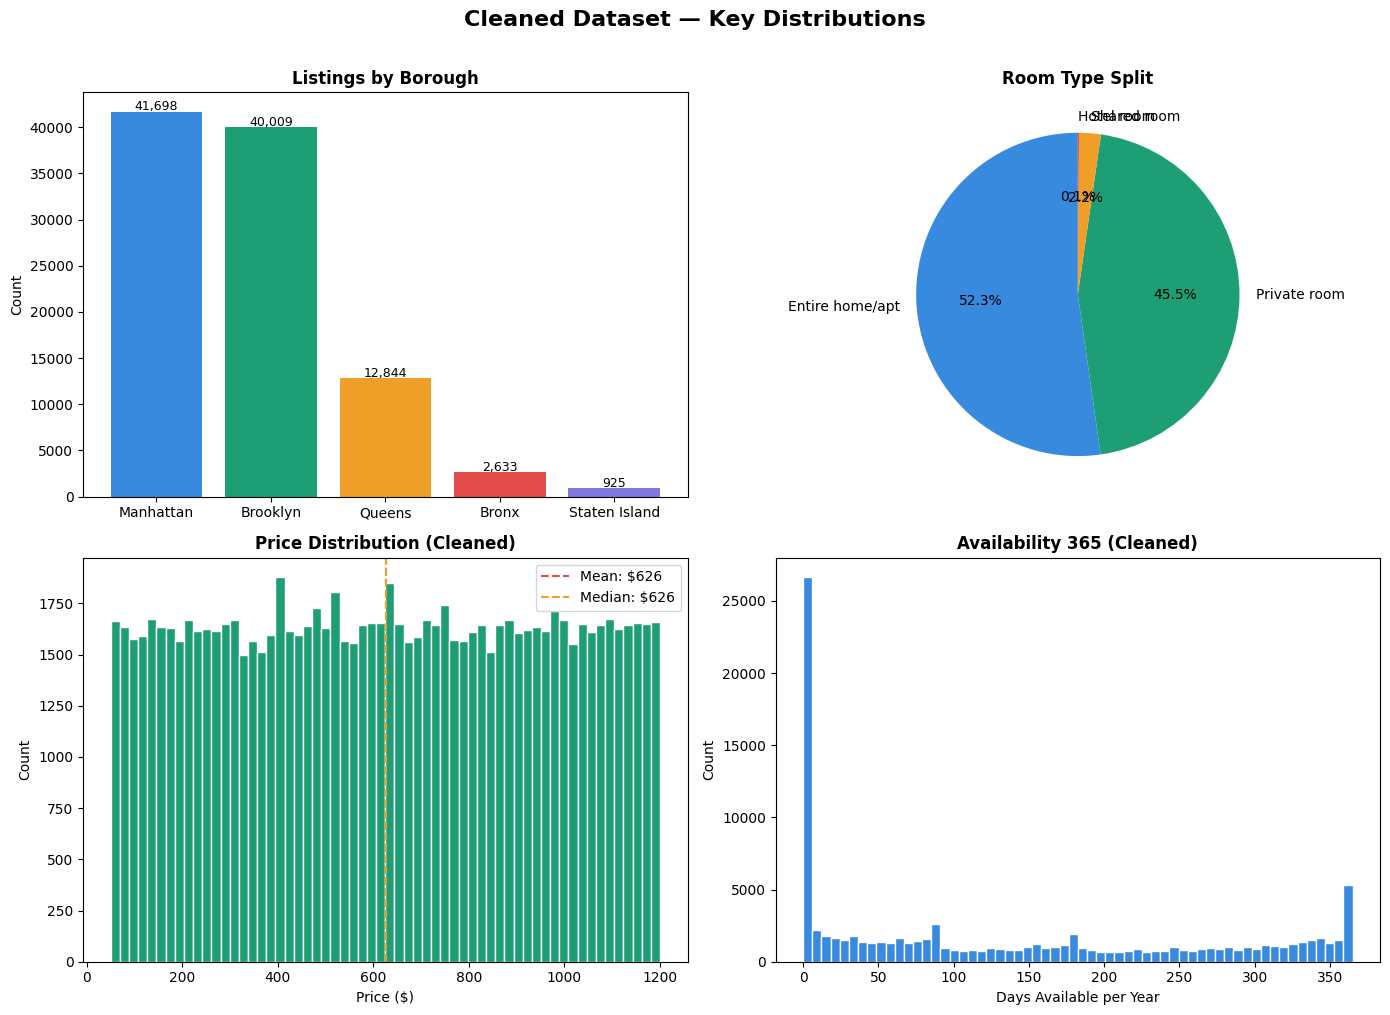

In [107]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cleaned Dataset — Key Distributions', fontsize=16, fontweight='bold', y=1.01)

# 1. Borough distribution
borough_counts = df['borough'].value_counts()
axes[0,0].bar(borough_counts.index, borough_counts.values,
              color=['#378ADD','#1D9E75','#EF9F27','#E24B4A','#7F77DD'])
axes[0,0].set_title('Listings by Borough', fontweight='bold')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(borough_counts.values):
    axes[0,0].text(i, v + 150, f'{v:,}', ha='center', fontsize=9)

# 2. Room type distribution
room_counts = df['room_type'].value_counts()
colors_r = ['#378ADD','#1D9E75','#EF9F27','#E24B4A']
axes[0,1].pie(room_counts.values, labels=room_counts.index,
              autopct='%1.1f%%', colors=colors_r, startangle=90)
axes[0,1].set_title('Room Type Split', fontweight='bold')

# 3. Price distribution (cleaned)
axes[1,0].hist(df['price'].dropna(), bins=60, color='#1D9E75', edgecolor='white')
axes[1,0].set_title('Price Distribution (Cleaned)', fontweight='bold')
axes[1,0].set_xlabel('Price ($)')
axes[1,0].set_ylabel('Count')
axes[1,0].axvline(df['price'].mean(),   color='#E24B4A', linestyle='--',
                  label=f"Mean: ${df['price'].mean():.0f}")
axes[1,0].axvline(df['price'].median(), color='#EF9F27', linestyle='--',
                  label=f"Median: ${df['price'].median():.0f}")
axes[1,0].legend()

# 4. Availability 365 distribution (cleaned)
axes[1,1].hist(df['availability_365'].dropna(), bins=60, color='#378ADD', edgecolor='white')
axes[1,1].set_title('Availability 365 (Cleaned)', fontweight='bold')
axes[1,1].set_xlabel('Days Available per Year')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

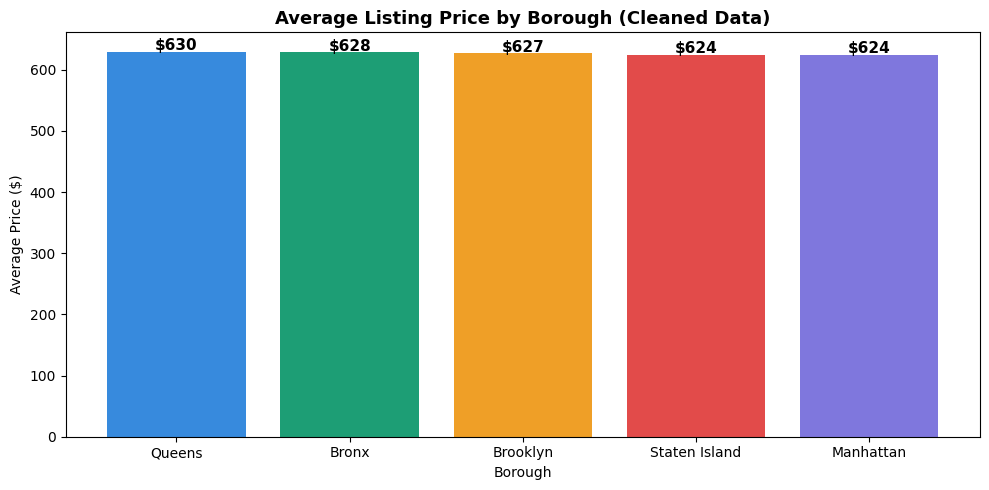

In [108]:
# Average price by borough — clean look
fig, ax = plt.subplots(figsize=(10, 5))

avg_price = df.groupby('borough')['price'].mean().sort_values(ascending=False)
bars = ax.bar(avg_price.index, avg_price.values,
              color=['#378ADD','#1D9E75','#EF9F27','#E24B4A','#7F77DD'])
ax.set_title('Average Listing Price by Borough (Cleaned Data)', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Price ($)')
ax.set_xlabel('Borough')

for bar, val in zip(bars, avg_price.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'${val:.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

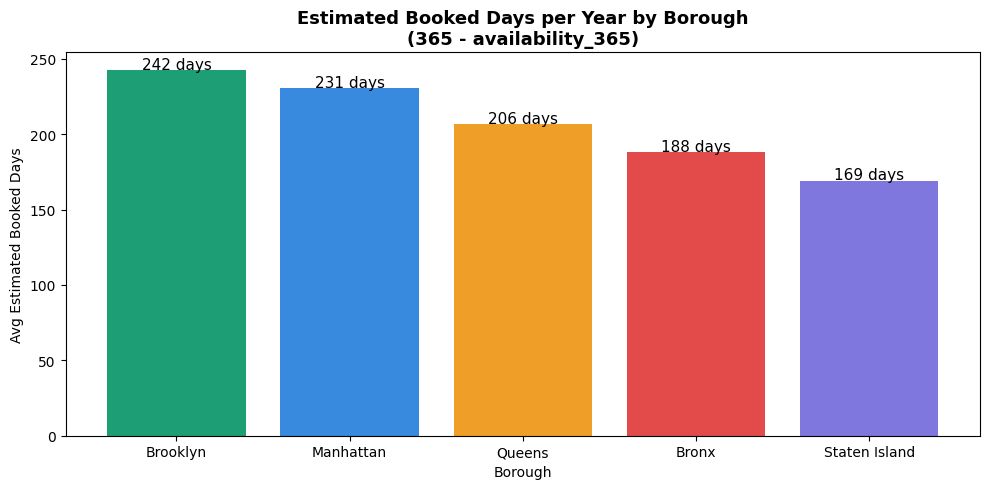


This is your key booking demand insight — ready for deeper SQL analysis!


In [109]:
# Booking demand proxy: avg (365 - availability) = estimated booked days
df['est_booked_days'] = 365 - df['availability_365']

fig, ax = plt.subplots(figsize=(10, 5))
demand = df.groupby('borough')['est_booked_days'].mean().sort_values(ascending=False)
bars = ax.bar(demand.index, demand.values,
              color=['#1D9E75','#378ADD','#EF9F27','#E24B4A','#7F77DD'])
ax.set_title('Estimated Booked Days per Year by Borough\n(365 - availability_365)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Estimated Booked Days')
ax.set_xlabel('Borough')

for bar, val in zip(bars, demand.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f} days', ha='center', fontsize=11)

plt.tight_layout()
plt.show()
print()
print("This is your key booking demand insight — ready for deeper SQL analysis!")

In [110]:
len(df)

98109

In [111]:
# df.drop(columns=['est_booked_days'], inplace=True)  # drop temp column before export

output_path = 'Airbnb_Cleaned.csv'
df.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to: {output_path}")
print(f"  Rows    : {len(df):,}")
print(f"  Columns : {df.shape[1]}")

Cleaned dataset saved to: Airbnb_Cleaned.csv
  Rows    : 98,109
  Columns : 22


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98109 entries, 0 to 102057
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   listing_id           98109 non-null  object 
 1   host_id              98109 non-null  object 
 2   host_verified        98109 non-null  object 
 3   host_name            98109 non-null  object 
 4   borough              98109 non-null  object 
 5   neighbourhood        98109 non-null  object 
 6   latitude             98109 non-null  float64
 7   longitude            98109 non-null  float64
 8   instant_bookable     98109 non-null  object 
 9   cancellation_policy  98109 non-null  object 
 10  room_type            98109 non-null  object 
 11  construction_year    98109 non-null  float64
 12  price                98109 non-null  float64
 13  service_fee          98109 non-null  float64
 14  minimum_nights       98109 non-null  float64
 15  number_of_reviews    98109 non-null  flo

In [121]:
avg_occupancy = ((df['est_booked_days']/365)*100).mean()
print(F"Average Occupancy rate across all listings: {avg_occupancy:.2f}%")

Average Occupancy rate across all listings: 63.15%


In [113]:
pip install psycopg2-binary sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [114]:
from sqlalchemy import create_engine

# ── UPDATE THESE WITH YOUR CREDENTIALS ──
DB_USER     = 'postgres'
DB_PASSWORD = '1405'
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'airbnb_db'
TABLE_NAME  = 'listings'

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

print(f"Loading {len(df):,} rows into PostgreSQL table '{TABLE_NAME}'...")

df.to_sql(
    TABLE_NAME,
    engine,
    if_exists='replace',   # replace if table already exists
    index=False,
    method='multi',        # batch insert — faster
    chunksize=1000
)

print(f"Done! Table '{TABLE_NAME}' is ready in database '{DB_NAME}'.")
print()
print("You can now open pgAdmin or psql and run:")
print(f"  SELECT COUNT(*) FROM {TABLE_NAME};")
print(f"  SELECT * FROM {TABLE_NAME} LIMIT 5;")

Loading 98,109 rows into PostgreSQL table 'listings'...
Done! Table 'listings' is ready in database 'airbnb_db'.

You can now open pgAdmin or psql and run:
  SELECT COUNT(*) FROM listings;
  SELECT * FROM listings LIMIT 5;


---

**Project flow complete:**
```
Raw CSV  →  Python EDA & Cleaning  →  Airbnb_Cleaned.csv  →  PostgreSQL  →  SQL Analysis  →  Dashboard
```